In [97]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [98]:

data = pd.read_csv("spam.csv",encoding = 'latin-1')
data

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN
...,...,...,...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...,NaN,NaN,NaN
5568,ham,Will Ì_ b going to esplanade fr home?,NaN,NaN,NaN
5569,ham,"Pity, * was in mood for that. So...any other s...",NaN,NaN,NaN
5570,ham,The guy did some bitching but I acted like i'd...,NaN,NaN,NaN


##### 1.Data Inspection

In [99]:
data.shape

(5572, 5)

In [100]:
data.columns

Index(['v1', 'v2', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'], dtype='object')

In [101]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   v1          5572 non-null   object
 1   v2          5572 non-null   object
 2   Unnamed: 2  50 non-null     object
 3   Unnamed: 3  12 non-null     object
 4   Unnamed: 4  6 non-null      object
dtypes: object(5)
memory usage: 217.8+ KB


In [102]:
# Droping non usefull columns

data.drop(['Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4'],axis = 1,inplace= True)

In [103]:
data.head()

,v1,v2
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


In [104]:
# Renaming columns name

data= data.rename(columns = {'v1':'target','v2':'text'})
data

,target,text
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


#### 2. Data Cleaning

In [105]:
# Handling Null values
data.isnull().sum()

target    0
text      0
dtype: int64

In [106]:
#Handling Duplicates values

data.duplicated().sum()

403

In [107]:
data.shape

(5572, 2)

In [108]:
data.drop_duplicates(inplace = True)

In [109]:
data.duplicated().sum()

0

In [110]:
data.shape

(5169, 2)

In [111]:
#method 1
data['target'] = data['target'].map({'ham':0,'spam':1})

In [112]:
#method 2
data['target'] = data['target'].replace(['ham', 'spam'], [0, 1])

In [113]:
#method 3
from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()
data['target'] = encoder.fit_transform(data['target'])


In [114]:
data

,target,text
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...
5568,0,Will Ì_ b going to esplanade fr home?
5569,0,"Pity, * was in mood for that. So...any other s..."
5570,0,The guy did some bitching but I acted like i'd...


In [115]:
data.dtypes

target     int64
text      object
dtype: object

#### 3. EDA

In [116]:
data['target'].value_counts()

target
0    4516
1     653
Name: count, dtype: int64

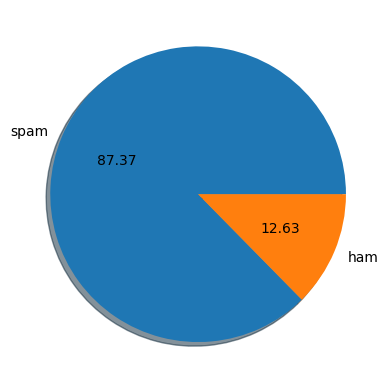

In [117]:
plt.pie(data['target'].value_counts(),labels=['spam','ham'],autopct = "%.2f",shadow= True)
plt.show()

In [118]:
# Feature Engineering

In [119]:
data['Number_of_character'] = data['text'].str.len()

In [120]:
data

,target,text,Number_of_character
0,0,"Go until jurong point, crazy.. Available only ...",111
1,0,Ok lar... Joking wif u oni...,29
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155
3,0,U dun say so early hor... U c already then say...,49
4,0,"Nah I don't think he goes to usf, he lives aro...",61
...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161
5568,0,Will Ì_ b going to esplanade fr home?,37
5569,0,"Pity, * was in mood for that. So...any other s...",57
5570,0,The guy did some bitching but I acted like i'd...,125


In [121]:
from nltk.tokenize import word_tokenize,sent_tokenize

In [122]:
data['Number_of_word'] = data['text'].apply({lambda x:len(word_tokenize(x)) })

In [123]:
data

,target,text,Number_of_character,Number_of_word
0,0,"Go until jurong point, crazy.. Available only ...",111,24
1,0,Ok lar... Joking wif u oni...,29,8
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37
3,0,U dun say so early hor... U c already then say...,49,13
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15
...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35
5568,0,Will Ì_ b going to esplanade fr home?,37,9
5569,0,"Pity, * was in mood for that. So...any other s...",57,15
5570,0,The guy did some bitching but I acted like i'd...,125,27


In [124]:
data['Number_of_sentences'] = data['text'].apply({lambda x:len(sent_tokenize(x)) })

In [125]:
data

,target,text,Number_of_character,Number_of_word,Number_of_sentences
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2
1,0,Ok lar... Joking wif u oni...,29,8,2
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2
3,0,U dun say so early hor... U c already then say...,49,13,1
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1
...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2
5570,0,The guy did some bitching but I acted like i'd...,125,27,1


In [126]:
data[['Number_of_character','Number_of_word','Number_of_sentences']].describe()

,Number_of_character,Number_of_word,Number_of_sentences
count,5169.000000,5169.000000,5169.000000
mean,78.977945,18.455794,1.965564
std,58.236293,13.324758,1.448541
min,2.000000,1.000000,1.000000
25%,36.000000,9.000000,1.000000
50%,60.000000,15.000000,1.000000
75%,117.000000,26.000000,2.000000
max,910.000000,220.000000,38.000000


In [127]:
# ham
data[data['target'] == 0][['Number_of_character','Number_of_word','Number_of_sentences']].describe()

,Number_of_character,Number_of_word,Number_of_sentences
count,4516.000000,4516.000000,4516.000000
mean,70.459256,17.123782,1.820195
std,56.358207,13.493970,1.383657
min,2.000000,1.000000,1.000000
25%,34.000000,8.000000,1.000000
50%,52.000000,13.000000,1.000000
75%,90.000000,22.000000,2.000000
max,910.000000,220.000000,38.000000


In [128]:
#spam
data[data['target'] == 1][['Number_of_character','Number_of_word','Number_of_sentences']].describe()

,Number_of_character,Number_of_word,Number_of_sentences
count,653.000000,653.000000,653.000000
mean,137.891271,27.667688,2.970904
std,30.137753,7.008418,1.488425
min,13.000000,2.000000,1.000000
25%,132.000000,25.000000,2.000000
50%,149.000000,29.000000,3.000000
75%,157.000000,32.000000,4.000000
max,224.000000,46.000000,9.000000


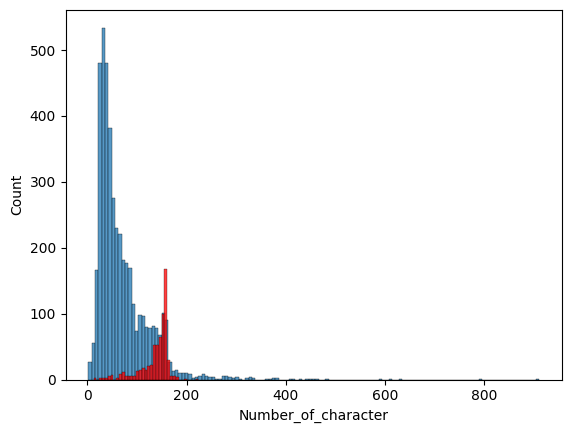

In [129]:
sns.histplot(data[data['target']==0]['Number_of_character'])
sns.histplot(data[data['target']==1]['Number_of_character'],color='red')
plt.show()


In [130]:
#  Correlation

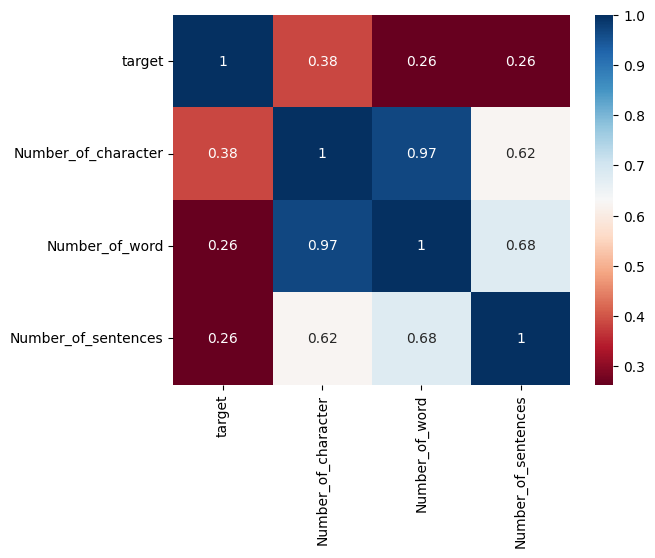

In [131]:
corr = data[['target','Number_of_character','Number_of_word','Number_of_sentences']].corr()
sns.heatmap(corr, annot = True, cmap='RdBu')
plt.show()

##### 4.Text Preprocessing

1. Install nltk and punkt
2. Perform tokenization on data
3. remove special character from the data
4. remove stopwords and puntuation from the data
5. Stemming

In [132]:
import nltk

In [133]:
from nltk.corpus import stopwords
import string

In [134]:
from nltk.stem.porter import PorterStemmer
ps = PorterStemmer()

In [135]:
def transform_text(text):
    text= text.lower()
    text = word_tokenize(text)
    
    y = []
    for i in text:
        if i.isalnum():
            y.append(i)
         
            
    
    text = y[:]
    y.clear()
  
    
    for i in text:
        if i  not in stopwords.words('english') and i  not in string.punctuation:
            y.append(i)
   
    
    text = y[:]
   
    
    for i in text:
        y.append(ps.stem(i))
        
    return " ".join(y)
   




    

    

In [136]:
transform_text("Go until jurong @ % point, how you're your are fine crazy.. Available only ..")

'go jurong point fine crazy available go jurong point fine crazi avail'

In [137]:
data['transformed_text'] = data['text'].apply(transform_text)

In [138]:
data

,target,text,Number_of_character,Number_of_word,Number_of_sentences,transformed_text
0,0,"Go until jurong point, crazy.. Available only ...",111,24,2,go jurong point crazy available bugis n great ...
1,0,Ok lar... Joking wif u oni...,29,8,2,ok lar joking wif u oni ok lar joke wif u oni
2,1,Free entry in 2 a wkly comp to win FA Cup fina...,155,37,2,free entry 2 wkly comp win fa cup final tkts 2...
3,0,U dun say so early hor... U c already then say...,49,13,1,u dun say early hor u c already say u dun say ...
4,0,"Nah I don't think he goes to usf, he lives aro...",61,15,1,nah think goes usf lives around though nah thi...
...,...,...,...,...,...,...
5567,1,This is the 2nd time we have tried 2 contact u...,161,35,4,2nd time tried 2 contact u pound prize 2 claim...
5568,0,Will Ì_ b going to esplanade fr home?,37,9,1,b going esplanade fr home b go esplanad fr home
5569,0,"Pity, * was in mood for that. So...any other s...",57,15,2,pity mood suggestions piti mood suggest
5570,0,The guy did some bitching but I acted like i'd...,125,27,1,guy bitching acted like interested buying some...


In [139]:
from wordcloud import WordCloud
wc = WordCloud(width=300,height=300,min_font_size=5,background_color='white')

In [140]:
spam_wc = wc.generate(data[data['target'] == 1]['transformed_text'].str.cat(sep=" "))

In [141]:
spam_wc

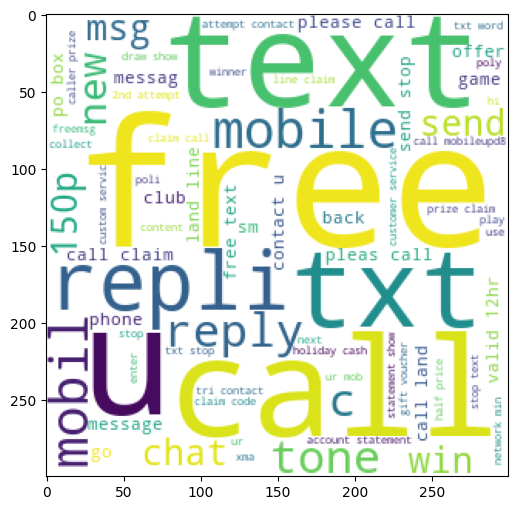

In [142]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [143]:
ham_wc = wc.generate(data[data['target'] == 0]['transformed_text'].str.cat(sep=" "))

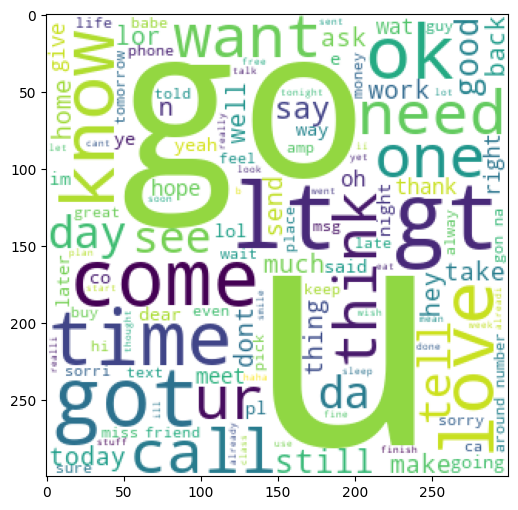

In [144]:
plt.figure(figsize=(15,6))
plt.imshow(spam_wc)

In [145]:
spam_corpus = []
for msg in data[data['target'] == 1]['transformed_text'].tolist():
    for word in msg.split():
        spam_corpus.append(word)

In [146]:
len(spam_corpus)

19878

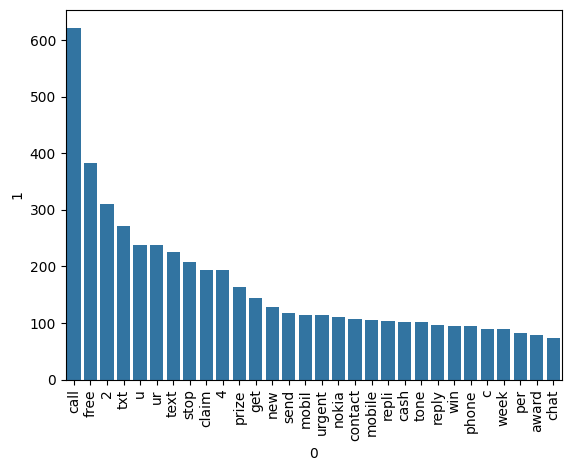

In [147]:
from collections import Counter
df= pd.DataFrame(Counter(spam_corpus).most_common(30))
sns.barplot(x=df[0],y=df[1])
plt.xticks(rotation='vertical')
plt.show()

In [51]:
pd.DataFrame(Counter(spam_corpus).most_common(30))

,0,1
0,call,622
1,free,382
2,2,310
3,txt,271
4,u,238
5,ur,238
6,text,226
7,stop,208
8,claim,194
9,4,194


In [148]:
from sklearn.feature_extraction.text import CountVectorizer,TfidfVectorizer

In [222]:
tf = TfidfVectorizer(max_features= 3000)
cv =  CountVectorizer()

In [150]:
# Dependant and Independent Feature

In [223]:
X = tf.fit_transform(data['transformed_text']).toarray()

In [224]:
X


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [153]:
y = data['target']

In [225]:
from sklearn.model_selection import train_test_split

In [226]:
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size= 0.2, random_state= 42)

In [242]:
# Feature Scaling

from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X = scaler.fit_transform(X)

In [243]:
X

array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [ ]:
# appending the num_character col to X
#X = np.hstack((X,data['Number_of_character'].values.reshape(-1,1)))

#### 5.Model Building

In [244]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB,MultinomialNB,BernoulliNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.ensemble import BaggingClassifier
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score,confusion_matrix,precision_score

In [ ]:
def eval_model(model,X_train,y_train,X_test,y_test):
    model = model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    
    #confusion_matrix= confusion_matrix (y_test,y_pred)
    accuracy= accuracy_score(y_test,y_pred)
    precision= precision_score(y_test,y_pred)
    
    result = pd.DataFrame({
        'Accuracy': [accuracy],
        'Precision': [precision]
    })
    return result

  

In [77]:
#Naiye Bayes

In [158]:
gnb =  GaussianNB()

In [159]:
gnb = eval_model(gnb,X_train,y_train,X_test,y_test)
gnb


,Accuracy,Precision
0,0.883946,0.556054


In [160]:
mnb = MultinomialNB()
mnb= eval_model(mnb,X_train,y_train,X_test,y_test)
mnb

,Accuracy,Precision
0,0.958414,0.793103


In [161]:
bnb =  BernoulliNB()
bnb=eval_model(bnb,X_train,y_train,X_test,y_test)
bnb


,Accuracy,Precision
0,0.966151,0.974138


In [66]:
#Random Forest

In [162]:
rf = RandomForestClassifier(n_estimators=50,random_state=2)
rf= eval_model(rf,X_train,y_train,X_test,y_test)
rf


,Accuracy,Precision
0,0.966151,1.0


In [163]:
#Logistic Regression
lr  = LogisticRegression()
lr= eval_model(lr,X_train,y_train,X_test,y_test)
lr

,Accuracy,Precision
0,0.976789,0.968992


In [80]:
#DecisionTree

In [164]:
dt = DecisionTreeClassifier(max_depth=5)
dt=eval_model(dt,X_train,y_train,X_test,y_test)
dt

,Accuracy,Precision
0,0.921663,0.932432


In [166]:
#knn
knn =   KNeighborsClassifier()
knn =eval_model(knn,X_train,y_train,X_test,y_test)
knn

,Accuracy,Precision
0,0.908124,1.0


In [167]:
#Bagging Classifier

bg = BaggingClassifier(n_estimators=50, random_state=2)
bg=eval_model(bg,X_train,y_train,X_test,y_test)
bg

,Accuracy,Precision
0,0.951644,0.862595


In [168]:
# Adaboost Classifier

abc = AdaBoostClassifier(n_estimators=50, random_state=2)
abc= eval_model(abc,X_train,y_train,X_test,y_test)
abc


,Accuracy,Precision
0,0.947776,0.847328


In [169]:
# Extra Trees Classifier
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
etc= eval_model(etc,X_train,y_train,X_test,y_test)
etc

,Accuracy,Precision
0,0.972921,0.991597


In [170]:
# Gradient Boosting Classifier

gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
gbdt =eval_model(gbdt,X_train,y_train,X_test,y_test)
gbdt


,Accuracy,Precision
0,0.937137,0.892157


In [171]:
# XGBoost Classifier
xgb = XGBClassifier(n_estimators=50,random_state=2)
xgb = eval_model(xgb,X_train,y_train,X_test,y_test)
xgb

,Accuracy,Precision
0,0.967118,0.917293


In [172]:
# Support Vector Machine
from sklearn.svm import SVC
svc = SVC(kernel='sigmoid', gamma=1.0)
svc= eval_model(svc,X_train,y_train,X_test,y_test)
svc


,Accuracy,Precision
0,0.886847,0.597222


In [ ]:
#Model Improvement

In [245]:
gnb =  GaussianNB()
mnb = MultinomialNB()
bnb =  BernoulliNB()
knn =   KNeighborsClassifier()
rf = RandomForestClassifier(n_estimators=50,random_state=2)
lr  = LogisticRegression()
dt = DecisionTreeClassifier(max_depth=5)
bg = BaggingClassifier(n_estimators=50, random_state=2)
abc = AdaBoostClassifier(n_estimators=50, random_state=2)
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)
gbdt = GradientBoostingClassifier(n_estimators=50,random_state=2)
xgb = XGBClassifier(n_estimators=50,random_state=2)
svc = SVC(kernel='sigmoid', gamma=1.0)

In [246]:
all_model = {
    "Logistic_Regression": lr,
    "Decision_Tree": dt,
    "Random Forest": rf,
    "KNN": knn,
    "Gaussian NB": gnb,
    "Multinomial NB": mnb,
    "BernoulliNB": bnb,
    "Adaboost": abc,
    "Bagging": bg,
    "XGBoost Classifier": xgb,
    "ExtraTreesClassifier": etc,
    "GradientBoostingClassifier": gbdt,
    "Support Vector Machine": svc
}


In [247]:
def eval_model(model,X_train,y_train,X_test,y_test):
    model = model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    
    accuracy= accuracy_score(y_test,y_pred)
    precision= precision_score(y_test,y_pred)
    return accuracy,precision

In [248]:
accuracy_scores = []
precision_scores = []


for name, model in all_model.items():

    current_accuracy, current_precision = eval_model(
        model, X_train, y_train, X_test, y_test
    )

    print("For", name)
    print("Accuracy -", current_accuracy)
    print("Precision -", current_precision)

    accuracy_scores.append(current_accuracy)
    precision_scores.append(current_precision)
    

For Logistic_Regression
Accuracy - 0.9593810444874274
Precision - 0.9478260869565217
For Decision_Tree
Accuracy - 0.9264990328820116
Precision - 0.8
For Random Forest
Accuracy - 0.9709864603481625
Precision - 0.9752066115702479
For KNN
Accuracy - 0.9032882011605415
Precision - 1.0
For Gaussian NB
Accuracy - 0.8665377176015474
Precision - 0.5147679324894515
For Multinomial NB
Accuracy - 0.97678916827853
Precision - 0.991869918699187
For BernoulliNB
Accuracy - 0.9777562862669246
Precision - 0.9692307692307692
For Adaboost
Accuracy - 0.9516441005802708
Precision - 0.8625954198473282
For Bagging
Accuracy - 0.9584139264990329
Precision - 0.875
For XGBoost Classifier
Accuracy - 0.9709864603481625
Precision - 0.9457364341085271
For ExtraTreesClassifier
Accuracy - 0.9796905222437138
Precision - 0.984375
For GradientBoostingClassifier
Accuracy - 0.9410058027079303
Precision - 0.92
For Support Vector Machine
Accuracy - 0.97678916827853
Precision - 0.9548872180451128


In [216]:
performance_df = pd.DataFrame({
    "Model_Name": all_model.keys(),
    "Accuracy": accuracy_scores,
    "Precision": precision_scores
}).sort_values('Precision', ascending = False)



In [217]:
performance_df

,Model_Name,Accuracy,Precision
2,Random Forest,0.966151,1.000000
3,KNN,0.908124,1.000000
10,ExtraTreesClassifier,0.972921,0.991597
6,BernoulliNB,0.966151,0.974138
0,Logistic_Regression,0.976789,0.968992
1,Decision_Tree,0.921663,0.932432
9,XGBoost Classifier,0.967118,0.917293
11,GradientBoostingClassifier,0.937137,0.892157
8,Bagging,0.951644,0.862595
7,Adaboost,0.947776,0.847328


In [218]:
performance_df1 = pd.melt(performance_df, id_vars = "Model_Name")

In [215]:
performance_df1

,Model_Name,variable,value
0,Random Forest,index,2.000000
1,KNN,index,3.000000
2,ExtraTreesClassifier,index,10.000000
3,BernoulliNB,index,6.000000
4,Logistic_Regression,index,0.000000
5,Decision_Tree,index,1.000000
6,XGBoost Classifier,index,9.000000
7,GradientBoostingClassifier,index,11.000000
8,Bagging,index,8.000000
9,Adaboost,index,7.000000


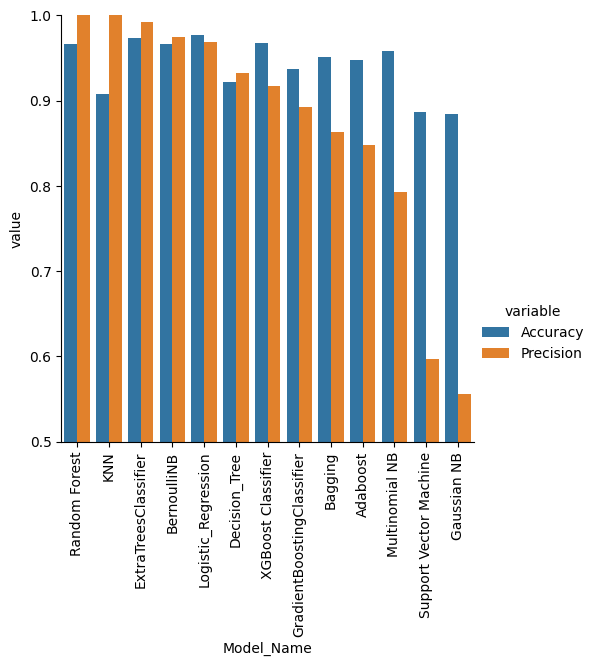

In [221]:
sns.catplot(x = 'Model_Name', y='value', 
               hue = 'variable',data=performance_df1, kind='bar',height=5)
plt.ylim(0.5,1.0)
plt.xticks(rotation='vertical')
plt.show()

In [237]:
temp_df = pd.DataFrame({'Model_Name':all_model.keys(),
                        'Accuracy_max_ft_3000':accuracy_scores,
                        'Precision_max_ft_3000':precision_scores}).sort_values('Precision_max_ft_3000',ascending=False)

In [238]:
temp_df

,Model_Name,Accuracy_max_ft_3000,Precision_max_ft_3000
3,KNN,0.903288,1.000000
5,Multinomial NB,0.976789,0.991870
10,ExtraTreesClassifier,0.979691,0.984375
2,Random Forest,0.970986,0.975207
6,BernoulliNB,0.977756,0.969231
12,Support Vector Machine,0.976789,0.954887
0,Logistic_Regression,0.959381,0.947826
9,XGBoost Classifier,0.970986,0.945736
11,GradientBoostingClassifier,0.941006,0.920000
8,Bagging,0.958414,0.875000


In [241]:
new_df = performance_df.merge(temp_df,on='Model_Name')
new_df

,Model_Name,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000
0,Random Forest,0.966151,1.000000,0.970986,0.975207
1,KNN,0.908124,1.000000,0.903288,1.000000
2,ExtraTreesClassifier,0.972921,0.991597,0.979691,0.984375
3,BernoulliNB,0.966151,0.974138,0.977756,0.969231
4,Logistic_Regression,0.976789,0.968992,0.959381,0.947826
5,Decision_Tree,0.921663,0.932432,0.925532,0.793103
6,XGBoost Classifier,0.967118,0.917293,0.970986,0.945736
7,GradientBoostingClassifier,0.937137,0.892157,0.941006,0.920000
8,Bagging,0.951644,0.862595,0.958414,0.875000
9,Adaboost,0.947776,0.847328,0.951644,0.862595


In [249]:
temp_df1 = pd.DataFrame({'Model_Name':all_model.keys(),
                        'Accuracy_scaling':accuracy_scores,
                        'Precision_scaling':precision_scores}).sort_values('Precision_scaling',ascending=False)

In [251]:
new_df_scaled = new_df.merge(temp_df1,on= 'Model_Name')


In [252]:
new_df_scaled 

,Model_Name,Accuracy,Precision,Accuracy_max_ft_3000,Precision_max_ft_3000,Accuracy_scaling,Precision_scaling
0,Random Forest,0.966151,1.000000,0.970986,0.975207,0.970986,0.975207
1,KNN,0.908124,1.000000,0.903288,1.000000,0.903288,1.000000
2,ExtraTreesClassifier,0.972921,0.991597,0.979691,0.984375,0.979691,0.984375
3,BernoulliNB,0.966151,0.974138,0.977756,0.969231,0.977756,0.969231
4,Logistic_Regression,0.976789,0.968992,0.959381,0.947826,0.959381,0.947826
5,Decision_Tree,0.921663,0.932432,0.925532,0.793103,0.926499,0.800000
6,XGBoost Classifier,0.967118,0.917293,0.970986,0.945736,0.970986,0.945736
7,GradientBoostingClassifier,0.937137,0.892157,0.941006,0.920000,0.941006,0.920000
8,Bagging,0.951644,0.862595,0.958414,0.875000,0.958414,0.875000
9,Adaboost,0.947776,0.847328,0.951644,0.862595,0.951644,0.862595


In [254]:
# Voting Classifier

rf = RandomForestClassifier(n_estimators=50,random_state=2)
mnb = MultinomialNB()
etc = ExtraTreesClassifier(n_estimators=50, random_state=2)

from sklearn.ensemble import VotingClassifier

In [255]:
voting = VotingClassifier(estimators=[('rf', rf), ('nb', mnb), ('et', etc)],voting='soft')
voting.fit(X_train,y_train)
y_pred = voting.predict(X_test)
print("Accuracy",accuracy_score(y_test,y_pred))
print("Precision",precision_score(y_test,y_pred))

Accuracy 0.9806576402321083
Precision 1.0


In [ ]:
import pickle
pickle.dump(tf,open('vectorizer.pkl','wb'))
pickle.dump(mnb,open('model.pkl','wb'))